# 🧪 Day 2 Exercise: Titanic Survival Prediction

**Time required:** 90–120 minutes  
**Goal:** Clean messy real data and build two models, compare them

## The Dataset Story

April 1912. 891 passengers. Who survived?

**Features available:**

- `Pclass` — ticket class (1=First, 2=Second, 3=Third)
- `Sex` — male/female
- `Age` — age in years (has MISSING values)
- `SibSp` — siblings/spouses aboard
- `Parch` — parents/children aboard
- `Fare` — ticket price
- `Embarked` — port of embarkation (C, Q, S)

**Target:** `Survived` (0 = No, 1 = Yes)= No, 1 = Yes)

### BLOCK 1: Load and First Look


In [15]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# Load the titanic dataset (pandas can load CSV directly from a URL)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Know your Data

In [16]:
print("=== DATA TYPES & MISSING VALUES ===")
df.info()

=== DATA TYPES & MISSING VALUES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### Count missing values per column

In [18]:
print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print(missing_report[missing_report['Missing'] > 0])


=== MISSING VALUES ===
          Missing  Percent
Age           177     19.9
Cabin         687     77.1
Embarked        2      0.2


### BLOCK 2: Exploratory Data Analysis

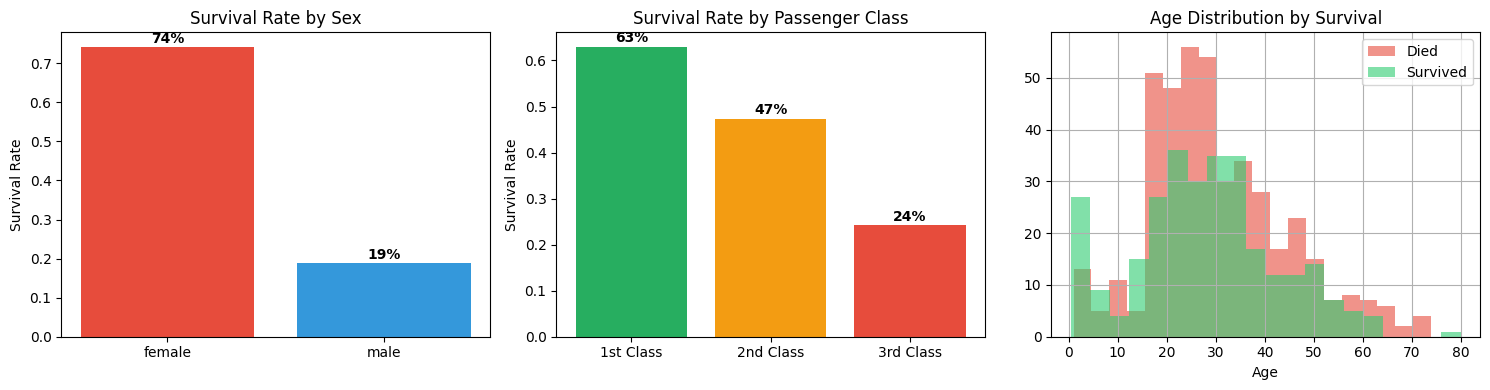


=== KEY INSIGHT FROM EDA ===
Women survived at 74% rate
Men survived at   19% rate
1st class:        63% survival rate
3rd class:        24% survival rate


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival by Sex
survival_by_sex = df.groupby('Sex')['Survived'].mean()
axes[0].bar(survival_by_sex.index, survival_by_sex.values, color=['#e74c3c','#3498db'])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')
for i, v in enumerate(survival_by_sex.values):
    axes[0].text(i, v + 0.01, f'{v:.0%}', ha='center', fontweight='bold')

# Survival by Class
survival_by_class = df.groupby('Pclass')['Survived'].mean()
axes[1].bar(['1st Class','2nd Class','3rd Class'],
            survival_by_class.values, color=['#27ae60','#f39c12','#e74c3c'])
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_ylabel('Survival Rate')
for i, v in enumerate(survival_by_class.values):
    axes[1].text(i, v + 0.01, f'{v:.0%}', ha='center', fontweight='bold')

# Age distribution by survival
df[df['Survived']==0]['Age'].dropna().hist(
    ax=axes[2], alpha=0.6, color='#e74c3c', label='Died', bins=20)
df[df['Survived']==1]['Age'].dropna().hist(
    ax=axes[2], alpha=0.6, color='#2ecc71', label='Survived', bins=20)
axes[2].set_title('Age Distribution by Survival')
axes[2].set_xlabel('Age')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n=== KEY INSIGHT FROM EDA ===")
print(f"Women survived at {df[df['Sex']=='female']['Survived'].mean():.0%} rate")
print(f"Men survived at   {df[df['Sex']=='male']['Survived'].mean():.0%} rate")
print(f"1st class:        {df[df['Pclass']==1]['Survived'].mean():.0%} survival rate")
print(f"3rd class:        {df[df['Pclass']==3]['Survived'].mean():.0%} survival rate")

#### BLOCK 3: Data Cleaning

##### Work on Copy, never the Original

In [38]:
df_clean = df.copy()

##### Fix 1. Drop columns with too many missing values
##### Cabin is 77% missing - not recoverable
##### Name, Ticket, PassengerId — identifiers, not predictors

In [39]:
df_clean = df_clean.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1)
print("After dropping useless columns:", df_clean.columns.tolist())

After dropping useless columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


##### Fix 1. Handle missing age value
##### Strategy: fill with MEDIAN age (robust to outliers)
##### DO NOT use mean — one 80-year-old skews it

In [40]:
median_age = df_clean['Age'].median()
df_clean['Age'].fillna(median_age, inplace=True)
print(f"\nFilled missing Age with median: {median_age}")


Filled missing Age with median: 28.0


##### FIX 3: Handle missing Embarked (only 2 rows)
##### Strategy: fill with most common value (mode)

In [41]:
most_common_port = df_clean['Embarked'].mode()[0]
df_clean['Embarked'].fillna(most_common_port, inplace=True)
print(f"Filled missing Embarked with mode: '{most_common_port}'")

Filled missing Embarked with mode: 'S'


##### FIX 4: Encode categorical variables ─────────────────────
##### Models need NUMBERS. 'male'/'female' must become 0/1
##### This is called "encoding"

In [42]:
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

# Embarked has 3 values (C, Q, S) → use one-hot encoding
# One-hot: create separate columns for each category
df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=True)
print("\nFinal clean dataset:")
print(df_clean.head())
print(f"\nShape: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")


Final clean dataset:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  22.0      1      0   7.2500       False        True
1         1       1    1  38.0      1      0  71.2833       False       False
2         1       3    1  26.0      0      0   7.9250       False        True
3         1       1    1  35.0      1      0  53.1000       False        True
4         0       3    0  35.0      0      0   8.0500       False        True

Shape: (891, 9)
Missing values remaining: 0


##### BONUS: Engineer a new feature 
##### Feature engineering = creating new signals from existing data
##### This alone can boost model performance more than switching algorithms

In [45]:
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)
print("New features added: FamilySize, IsAlone")

# Quick check: did being alone affect survival?
print(f"\nSolo travelers survived at: {df[df['SibSp']+df['Parch']==0]['Survived'].mean():.0%}")
print(f"Family travelers survived at: {df[df['SibSp']+df['Parch']>0]['Survived'].mean():.0%}")

New features added: FamilySize, IsAlone

Solo travelers survived at: 30%
Family travelers survived at: 51%


#### BLOCK 4: Build Two Models and Compare

##### Prepare Features and Target

In [46]:
feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
                'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S']

X = df_clean[feature_cols]
y = df_clean['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Survival rate in train: {y_train.mean():.0%}")
print(f"Survival rate in test:  {y_test.mean():.0%}")

Train set: (712, 10), Test set: (179, 10)
Survival rate in train: 38%
Survival rate in test:  39%


#### Model 1: Logistic Regression

In [47]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)


#### Model 2: Decision Tree

In [49]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

In [50]:
print("=" * 45)
print(f"  Logistic Regression Accuracy:  {lr_acc:.1%}")
print(f"  Decision Tree Accuracy:        {dt_acc:.1%}")
print("=" * 45)

  Logistic Regression Accuracy:  80.4%
  Decision Tree Accuracy:        76.0%


#### DEEP DIVE: What did each model get wrong?

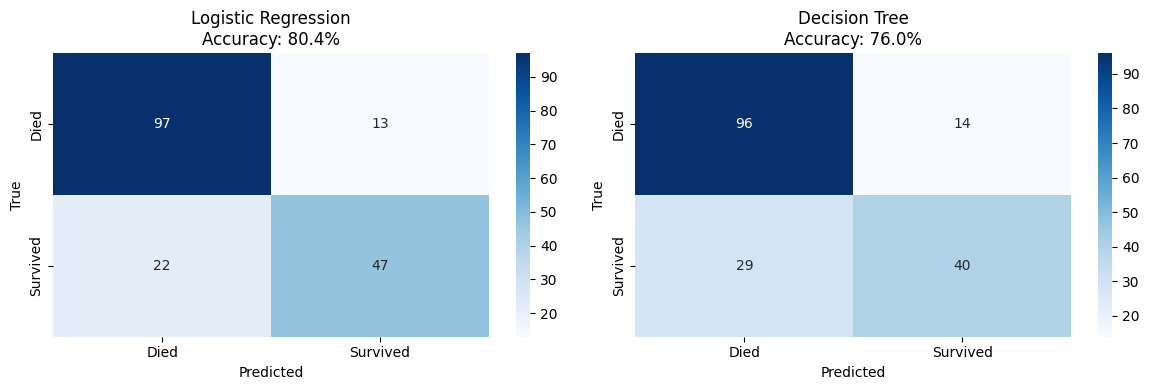

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, name in zip(axes,
                           [lr_pred, dt_pred],
                           ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Died','Survived'],
                yticklabels=['Died','Survived'])
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred):.1%}')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [53]:
# ── PROFESSIONAL METRIC: Classification Report ──────────────
print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, lr_pred, target_names=['Died','Survived']))

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

        Died       0.82      0.88      0.85       110
    Survived       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



#### BLOCK 5: Understand What Your Model Learned

##### What features matter most to Logistic Regression?

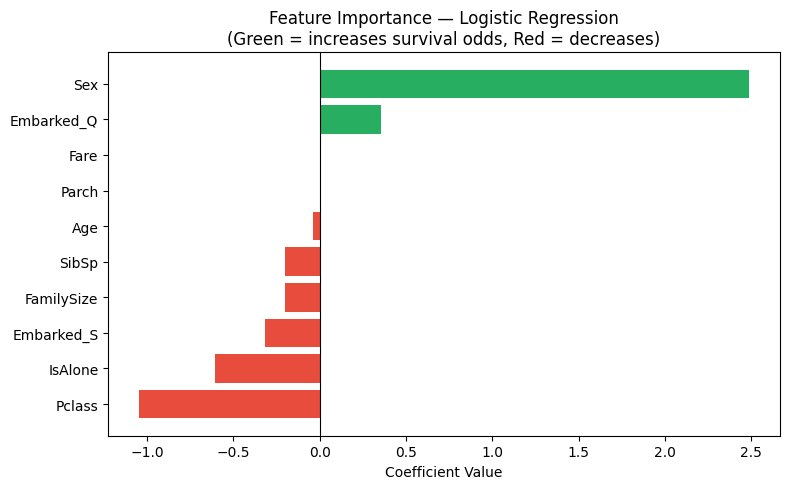


Top 3 factors INCREASING survival:
   Feature  Coefficient
      Fare     0.001940
Embarked_Q     0.355460
       Sex     2.490328

Top 3 factors DECREASING survival:
   Feature  Coefficient
    Pclass    -1.049051
   IsAlone    -0.603916
Embarked_S    -0.317236


In [54]:
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient')

plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if c < 0 else '#27ae60' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.title('Feature Importance — Logistic Regression\n'
          '(Green = increases survival odds, Red = decreases)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print("\nTop 3 factors INCREASING survival:")
print(coef_df.tail(3)[['Feature','Coefficient']].to_string(index=False))
print("\nTop 3 factors DECREASING survival:")
print(coef_df.head(3)[['Feature','Coefficient']].to_string(index=False))

##### Make a real prediction 
##### You are: 30-year-old woman, 1st class, traveling alone, paid £100

In [55]:
you = pd.DataFrame([[1, 1, 30, 0, 0, 100.0, 1, 1, 0, 0]],
                   columns=feature_cols)

prob = lr_model.predict_proba(you)[0]
print(f"\n30-year-old woman, 1st class, traveling alone:")
print(f"  Survival probability: {prob[1]:.1%}")
print(f"  Prediction: {'SURVIVED' if prob[1] > 0.5 else 'DID NOT SURVIVE'}")

# Now try: 25-year-old man, 3rd class
him = pd.DataFrame([[3, 0, 25, 0, 0, 8.0, 1, 1, 0, 0]],
                   columns=feature_cols)
prob2 = lr_model.predict_proba(him)[0]
print(f"\n25-year-old man, 3rd class, traveling alone:")
print(f"  Survival probability: {prob2[1]:.1%}")
print(f"  Prediction: {'SURVIVED' if prob2[1] > 0.5 else 'DID NOT SURVIVE'}")


30-year-old woman, 1st class, traveling alone:
  Survival probability: 93.6%
  Prediction: SURVIVED

25-year-old man, 3rd class, traveling alone:
  Survival probability: 13.0%
  Prediction: DID NOT SURVIVE
